In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
file_paths = sorted(glob.glob("csv_results/gender_sample_fraction1_*.csv"))
all_dfs = []

for path in file_paths:
    df = pd.read_csv(path)
    df["sample_fraction"] = float(path.split("_")[-1].replace(".csv", ""))
    all_dfs.append(df)

# Объединяем в один DataFrame
df_all = pd.concat(all_dfs, ignore_index=True)

In [3]:
len(df_all)

2670

In [4]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df_all[["metric_ripser_sum_H0", "metric_ripser_sum_H1"]])
weighted_sum = np.mean(scaled, axis=1)
df_all['ripser_weighted'] = weighted_sum

In [73]:
#combinations
all_metric_columns = []
for metric1 in metric_columns:
    for metric2 in metric_columns:
        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(df_all[[metric1, metric2]])
        weighted_sum = np.mean(scaled, axis=1)
        all_metric_columns.append(metric1 + "_" + metric2 + '_weighted')
        all_metric_columns.append(metric1 + "_" + metric2 + '_prod')
        df_all[metric1 + "_" + metric2 + '_weighted'] = weighted_sum
        df_all[metric1 + "_" + metric2 + '_prod'] = scaled[:,0] * scaled[:,1]

all_metric_columns += metric_columns

/home/dpetrovitch/venv/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/dpetrovitch/venv/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/dpetrovitch/venv/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/dpetrovitch/venv/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/dpetrovitch/venv/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/dpetrovitch/venv/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountere

In [24]:
metric_columns = [col for col in df_all.columns if col.startswith("metric_")] + ['ripser_weighted']

corr_records = []

# Вычисляем корреляцию с accuracy для каждой метрики при каждом sample_fraction
for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        if sub[metric].nunique() > 1:  # нужно хотя бы 2 уникальных значения для корреляции
            corr = sub[metric].corr(sub['roc_auc'])
            corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": np.abs(corr)
            })

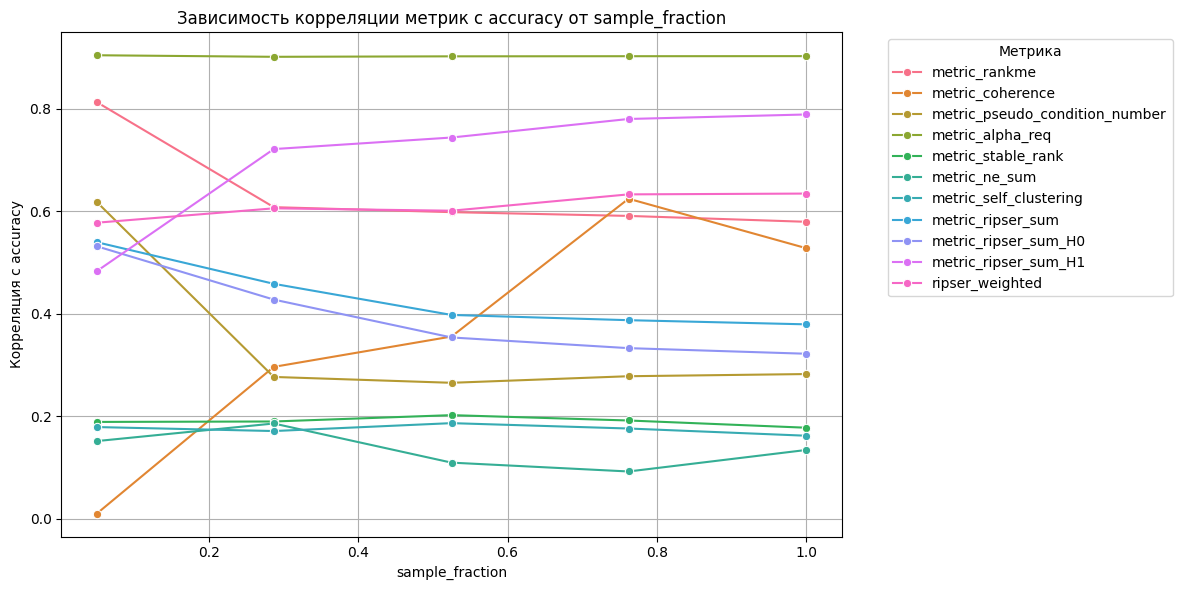

In [25]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [36]:
print(corr_df)

    sample_fraction                          metric  correlation
0             0.050                   metric_rankme     0.813366
1             0.050                metric_coherence     0.009505
2             0.050  metric_pseudo_condition_number     0.618338
3             0.050                metric_alpha_req     0.904871
4             0.050              metric_stable_rank     0.188692
5             0.050                   metric_ne_sum     0.151265
6             0.050          metric_self_clustering     0.178671
7             0.050               metric_ripser_sum     0.539736
8             0.050            metric_ripser_sum_H0     0.531806
9             0.050            metric_ripser_sum_H1     0.483082
10            0.050                 ripser_weighted     0.577791
11            0.287                   metric_rankme     0.608167
12            0.287                metric_coherence     0.296199
13            0.287  metric_pseudo_condition_number     0.276544
14            0.287      

In [35]:
mean_corr = corr_df[corr_df['sample_fraction'] <0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_alpha_req                  0.903354
metric_rankme                     0.710767
metric_ripser_sum_H1              0.602347
ripser_weighted                   0.591836
metric_ripser_sum                 0.499089
metric_ripser_sum_H0              0.479727
metric_pseudo_condition_number    0.447441
metric_stable_rank                0.189112
metric_self_clustering            0.174773
metric_ne_sum                     0.168441
metric_coherence                  0.152852
Name: correlation, dtype: float64

In [84]:
from scipy.stats import spearmanr


spear_corr_records = []

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in all_metric_columns:
        if sub[metric].nunique() > 1 and sub['accuracy'].nunique() > 1:
            corr, _ = spearmanr(sub[metric], sub['roc_auc'])
            spear_corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": np.abs(corr)
            })
            


/tmp/ipykernel_3255029/1552398705.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


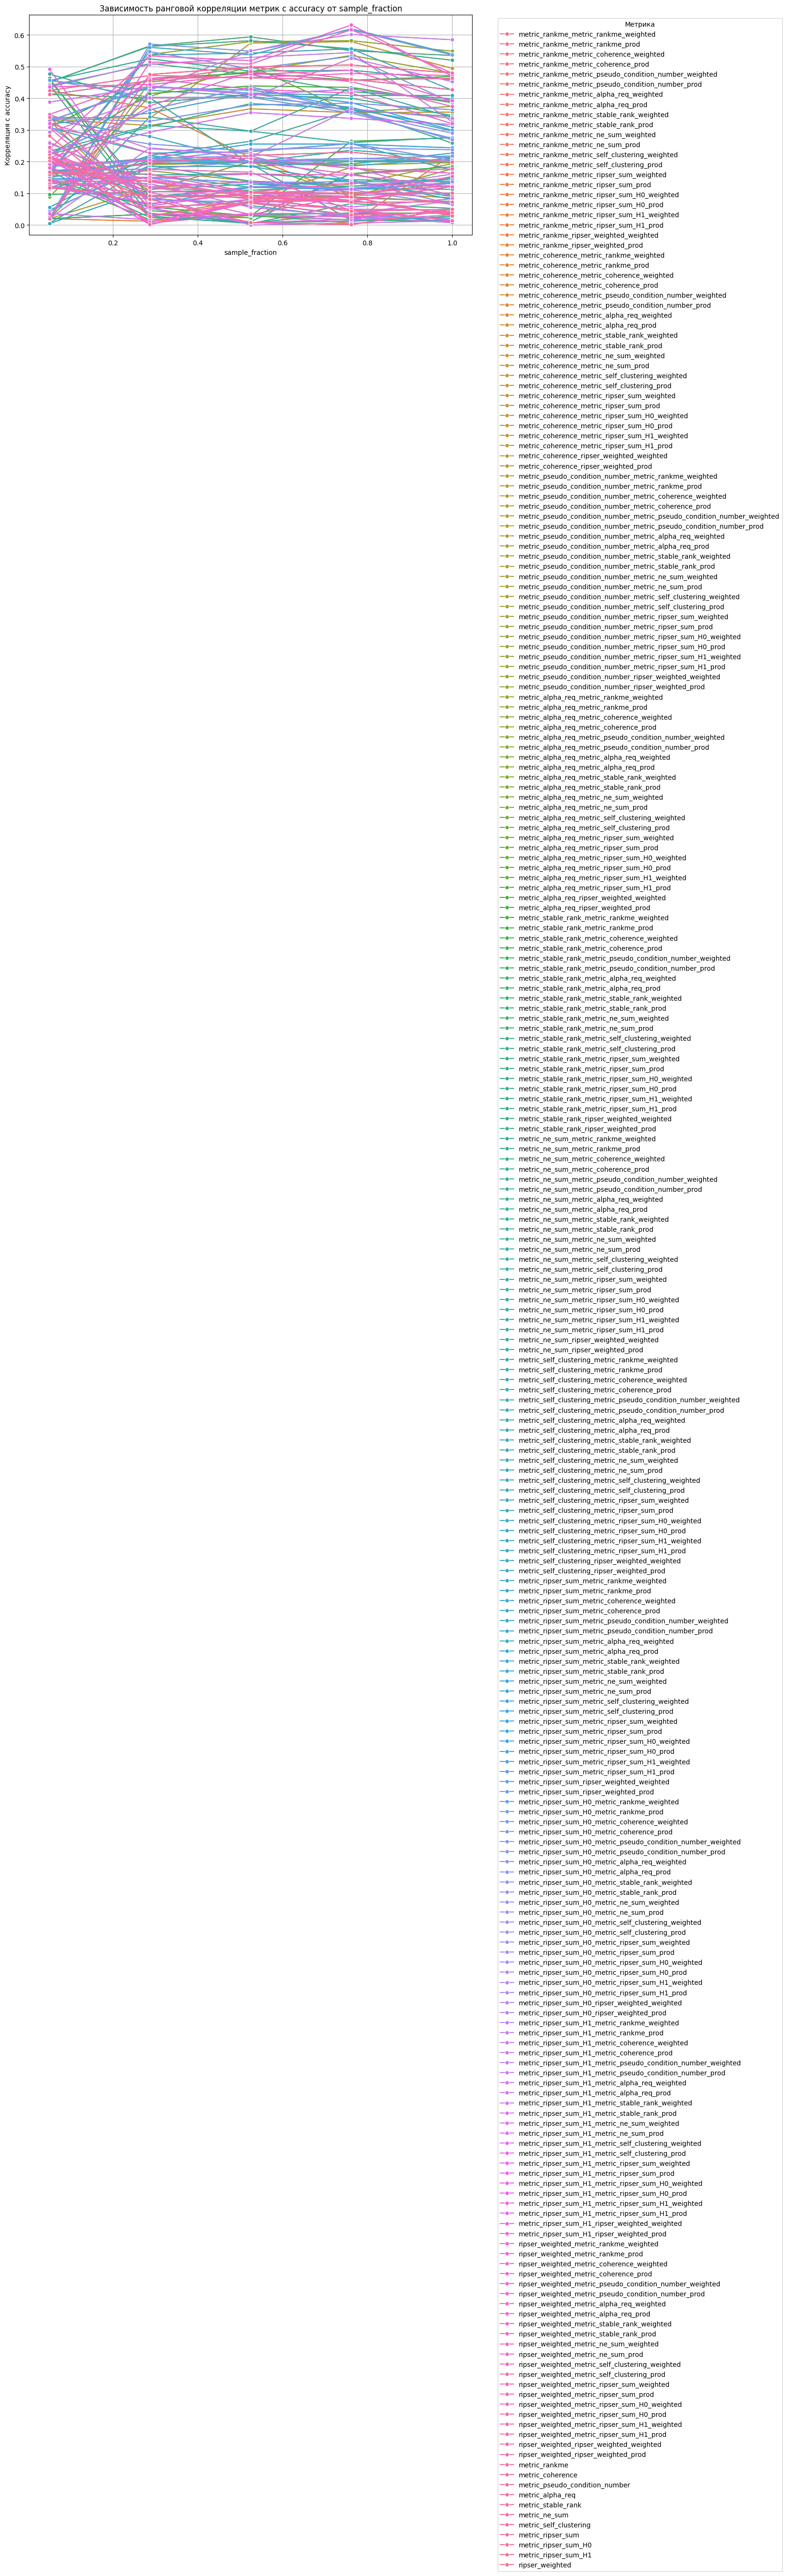

In [85]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [89]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_rankme_metric_ripser_sum_H1_prod': 0.5849624060150376,
 'metric_ripser_sum_H1_metric_rankme_prod': 0.5849624060150376,
 'metric_coherence_metric_alpha_req_weighted': 0.5488721804511278,
 'metric_alpha_req_metric_coherence_weighted': 0.5488721804511278,
 'metric_coherence_metric_ripser_sum_prod': 0.5398496240601504,
 'metric_ripser_sum_metric_coherence_prod': 0.5398496240601504,
 'metric_coherence_metric_ripser_sum_H0_prod': 0.5368421052631579,
 'metric_ripser_sum_H0_metric_coherence_prod': 0.5368421052631579,
 'metric_rankme_metric_ne_sum_weighted': 0.5353383458646617,
 'metric_ne_sum_metric_rankme_weighted': 0.5353383458646617,
 'metric_ne_sum_metric_rankme_prod': 0.5203007518796992,
 'metric_rankme_metric_ne_sum_prod': 0.5203007518796992,
 'metric_coherence_metric_pseudo_condition_number_weighted': 0.4947368421052631,
 'metric_pseudo_condition_number_metric_coherence_weighted': 0.4947368421052631,
 'metric_alpha_req_metric_coherence_prod': 0.4796992481203006,
 'metric_cohere

In [90]:
from scipy.stats import spearmanr


spear_corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in all_metric_columns:
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr, _ = spearmanr(check_data[metric], check_data['roc_auc'])
                spear_corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": np.abs(corr)
                })
            


/tmp/ipykernel_3255029/1552398705.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


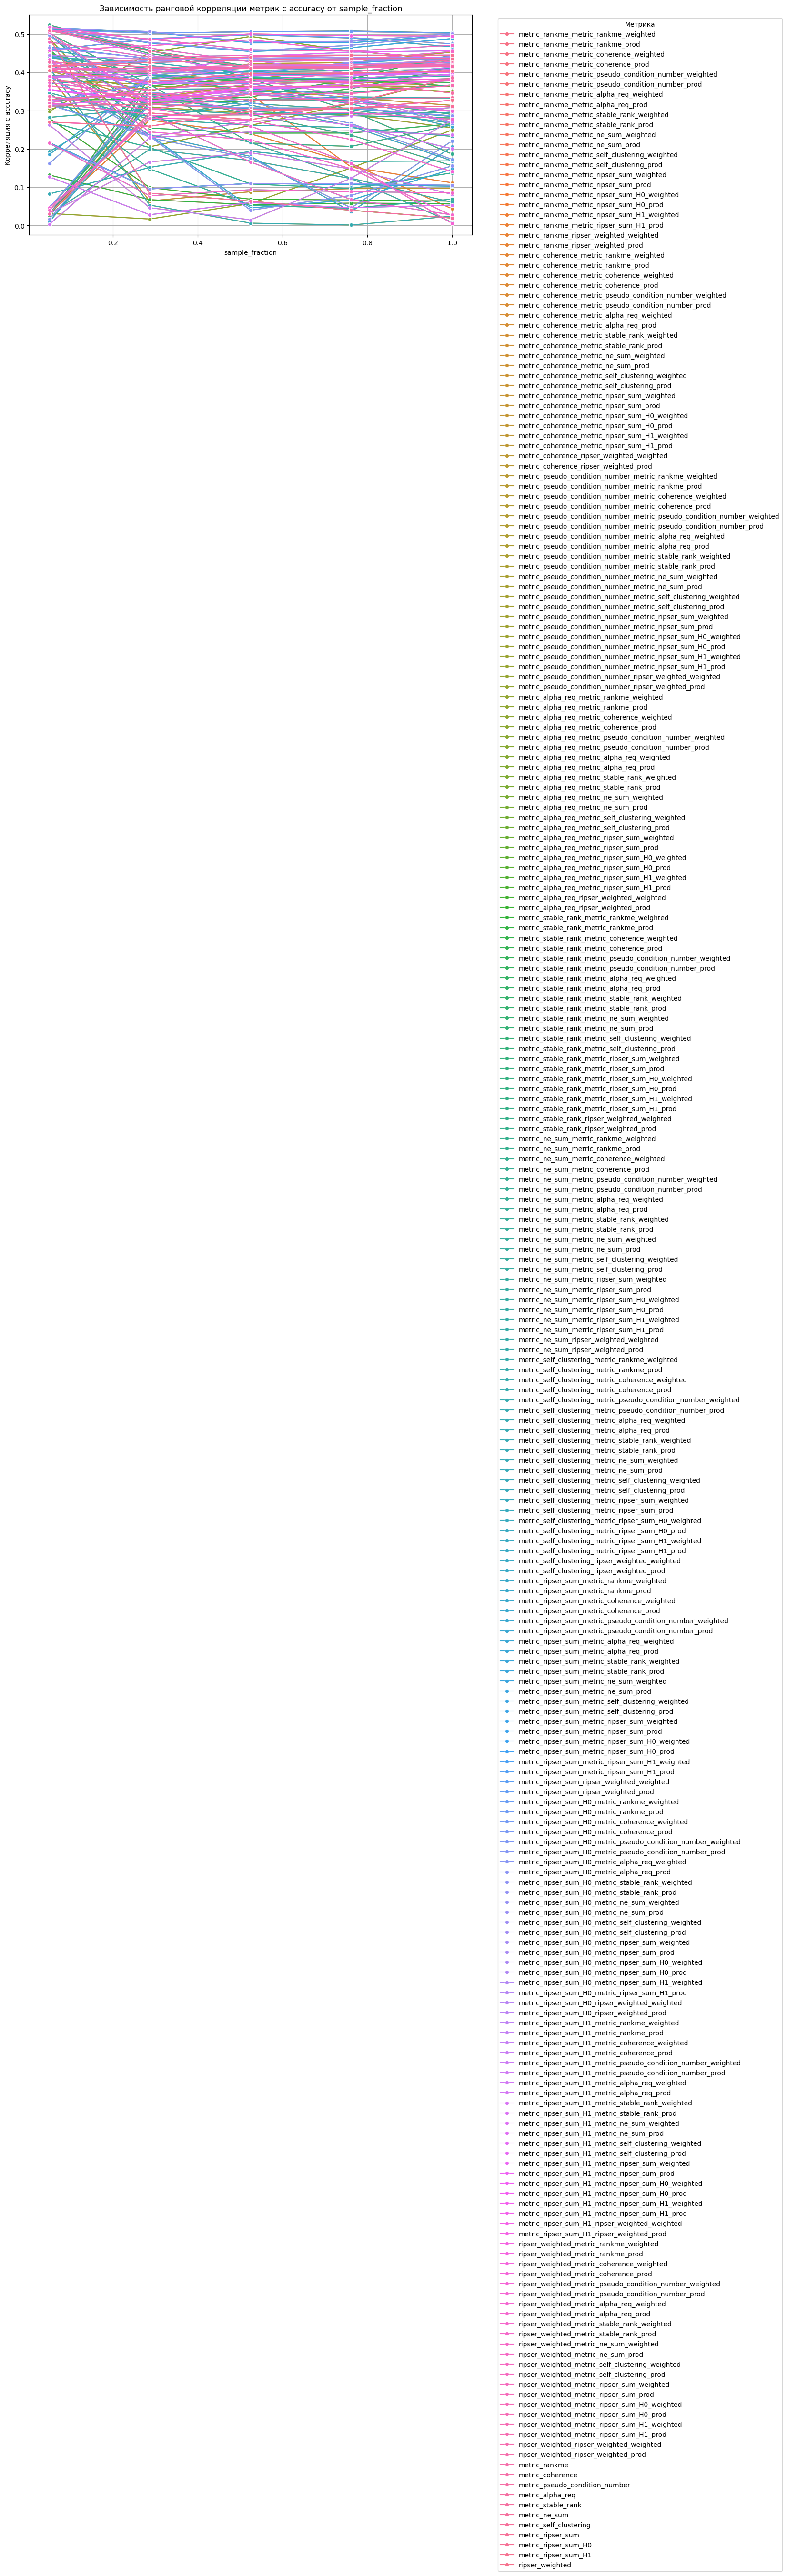

In [91]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [92]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_rankme_metric_ripser_sum_prod': 0.5066417363729393,
 'metric_ripser_sum_metric_rankme_prod': 0.5066417363729393,
 'metric_rankme_metric_ripser_sum_H0_prod': 0.5054215197036745,
 'metric_ripser_sum_H0_metric_rankme_prod': 0.5054215197036745,
 'metric_rankme_ripser_weighted_prod': 0.49893903501001463,
 'ripser_weighted_metric_rankme_prod': 0.49893903501001463,
 'metric_ripser_sum_H0_metric_ne_sum_prod': 0.49674959607006697,
 'metric_ne_sum_metric_ripser_sum_H0_prod': 0.49674959607006697,
 'metric_ne_sum_metric_ripser_sum_prod': 0.4946149853210179,
 'metric_ripser_sum_metric_ne_sum_prod': 0.4946149853210179,
 'metric_ne_sum_metric_ripser_sum_H0_weighted': 0.4829024874657673,
 'metric_ripser_sum_H0_metric_ne_sum_weighted': 0.4829024874657673,
 'metric_rankme_metric_ripser_sum_H0_weighted': 0.4820267024359044,
 'metric_ripser_sum_H0_metric_rankme_weighted': 0.4820267024359044,
 'metric_rankme_metric_ripser_sum_weighted': 0.47997942902947743,
 'metric_ripser_sum_metric_rankme_weight

In [52]:

corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr = check_data[metric].corr(check_data['roc_auc'])
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": np.abs(corr)
                })
     

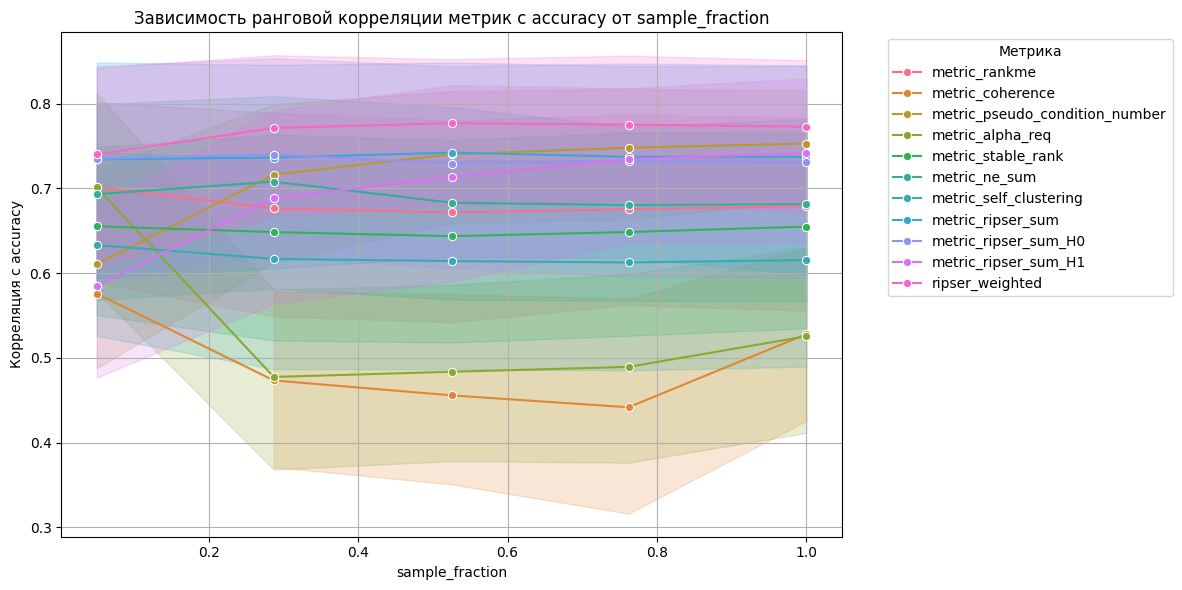

In [53]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [54]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
ripser_weighted                   0.767128
metric_ripser_sum                 0.737355
metric_ripser_sum_H0              0.733283
metric_pseudo_condition_number    0.713407
metric_ripser_sum_H1              0.692529
metric_ne_sum                     0.689080
metric_rankme                     0.680640
metric_stable_rank                0.650056
metric_self_clustering            0.618356
metric_alpha_req                  0.535358
metric_coherence                  0.476065
Name: correlation, dtype: float64

In [94]:
corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in all_metric_columns:
        for check, check_data in sub.groupby('runs'):
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr = check_data[metric].corr(check_data['roc_auc'])
                pick = check_data['roc_auc'].values[
                    np.argmax(np.sign(corr) * check_data[metric].values)]
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "auc": pick
                })

/tmp/ipykernel_3255029/3876850653.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


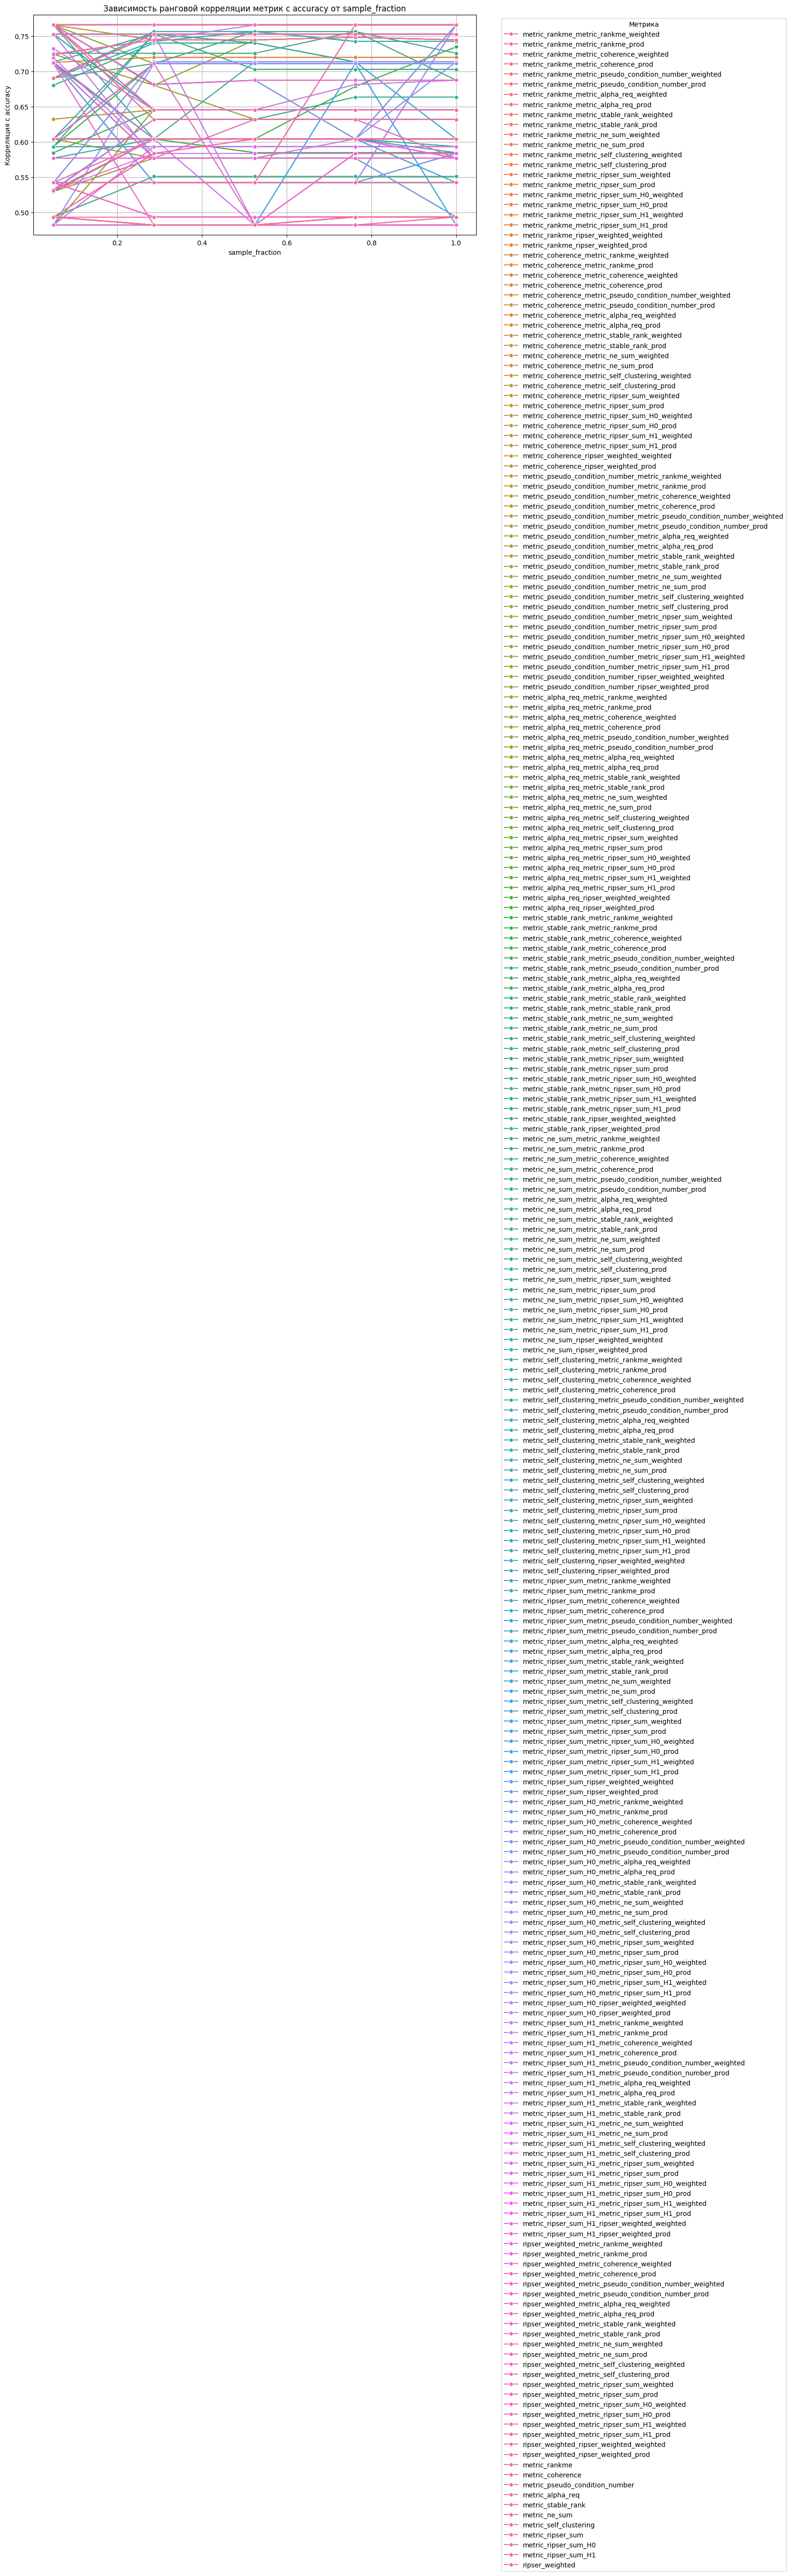

In [95]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [97]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_coherence_metric_rankme_weighted': 0.7657,
 'metric_rankme_metric_coherence_weighted': 0.7657,
 'metric_rankme_metric_pseudo_condition_number_weighted': 0.7657,
 'metric_rankme_metric_rankme_weighted': 0.7657,
 'metric_rankme_metric_rankme_prod': 0.7657,
 'metric_rankme_metric_ripser_sum_weighted': 0.7657,
 'metric_rankme_ripser_weighted_weighted': 0.7657,
 'metric_rankme_ripser_weighted_prod': 0.7657,
 'metric_rankme_metric_ripser_sum_H1_weighted': 0.7657,
 'metric_rankme_metric_ripser_sum_H0_weighted': 0.7657,
 'metric_rankme_metric_ripser_sum_H0_prod': 0.7657,
 'metric_pseudo_condition_number_metric_rankme_weighted': 0.7657,
 'metric_rankme': 0.7657,
 'metric_rankme_metric_ripser_sum_prod': 0.7657,
 'ripser_weighted_metric_rankme_prod': 0.7657,
 'ripser_weighted_metric_rankme_weighted': 0.7657,
 'metric_ripser_sum_metric_rankme_weighted': 0.7657,
 'metric_ripser_sum_metric_rankme_prod': 0.7657,
 'metric_ripser_sum_H1_metric_rankme_weighted': 0.7657,
 'metric_ripser_sum_H0_m

In [101]:
from collections import defaultdict
comb_w = defaultdict(dict)
comb_prod = defaultdict(dict)

for metric in metric_columns:
    for i in range(mean_corr.shape[0]):
        if metric in mean_corr.index.values[i]:
            if 'prod' in mean_corr.index.values[i]:
                comb_prod[metric][mean_corr.index.values[i]] = mean_corr.values[i]
            elif 'weighted' in mean_corr.index.values[i]:
                comb_w[metric][mean_corr.index.values[i]] = mean_corr.values[i]



In [102]:
for metric in metric_columns:
    comb_prod[metric] = pd.Series(comb_prod[metric])
    print (metric, comb_prod[metric].mean())
    comb_w[metric] = pd.Series(comb_w[metric])
    print (metric, comb_w[metric].mean())

metric_rankme 0.7119342857142857
metric_rankme 0.7252790476190476
metric_coherence 0.6368542857142858
metric_coherence 0.6448809523809524
metric_pseudo_condition_number 0.6569419047619046
metric_pseudo_condition_number 0.7116923809523812
metric_alpha_req 0.605395238095238
metric_alpha_req 0.6214238095238095
metric_stable_rank 0.6315009523809525
metric_stable_rank 0.624567619047619
metric_ne_sum 0.69824
metric_ne_sum 0.6990647619047617
metric_self_clustering 0.6224057142857145
metric_self_clustering 0.6334952380952382
metric_ripser 0.6250543859649123
metric_ripser 0.6142480701754385
metric_ripser_sum 0.6250543859649123
metric_ripser_sum 0.6142480701754385
metric_ripser_sum_H0 0.6365990476190475
metric_ripser_sum_H0 0.6235590476190476
metric_ripser_sum_H1 0.6065361904761906
metric_ripser_sum_H1 0.5810523809523809
ripser_weighted 0.5962495238095239
ripser_weighted 0.5887254545454546


In [127]:
params_cols=["batch_size","learning_rate",
    "split_count",
    "cnt_min",
    "cnt_max",
    "embedding_dim",
    "category_embedding_dim",
    "hidden_size"]

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for check, check_data in sub.groupby(combined):
            for metric in metric_columns:
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                    corr = check_data[metric].corr(check_data['roc_auc'])
                    pick = check_data['roc_auc'].values[
                        np.argmax(np.sign(corr) * check_data[metric].values)]
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "auc": pick
                    })

/tmp/ipykernel_3255029/1706364257.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_3255029/1706364257.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_3255029/1706364257.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.c

batch_size


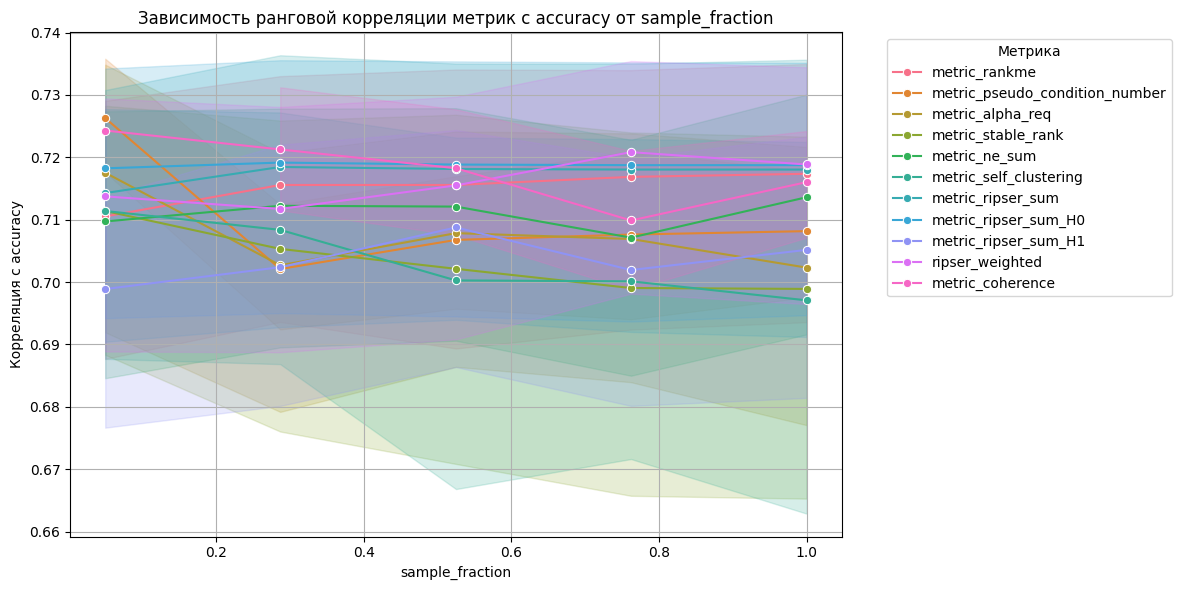

learning_rate


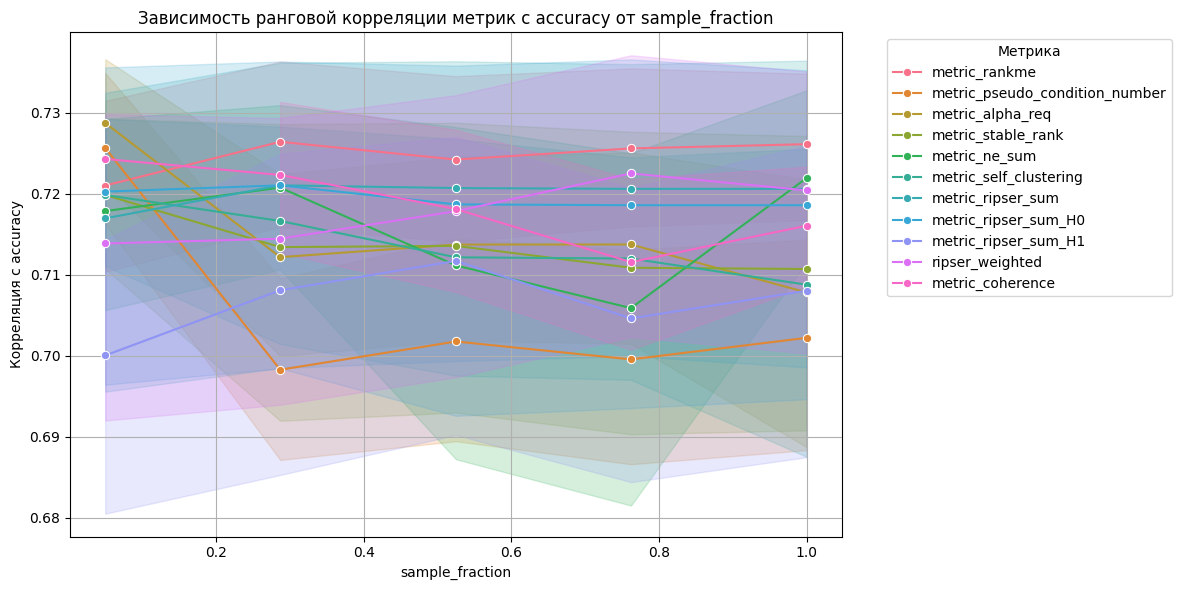

split_count


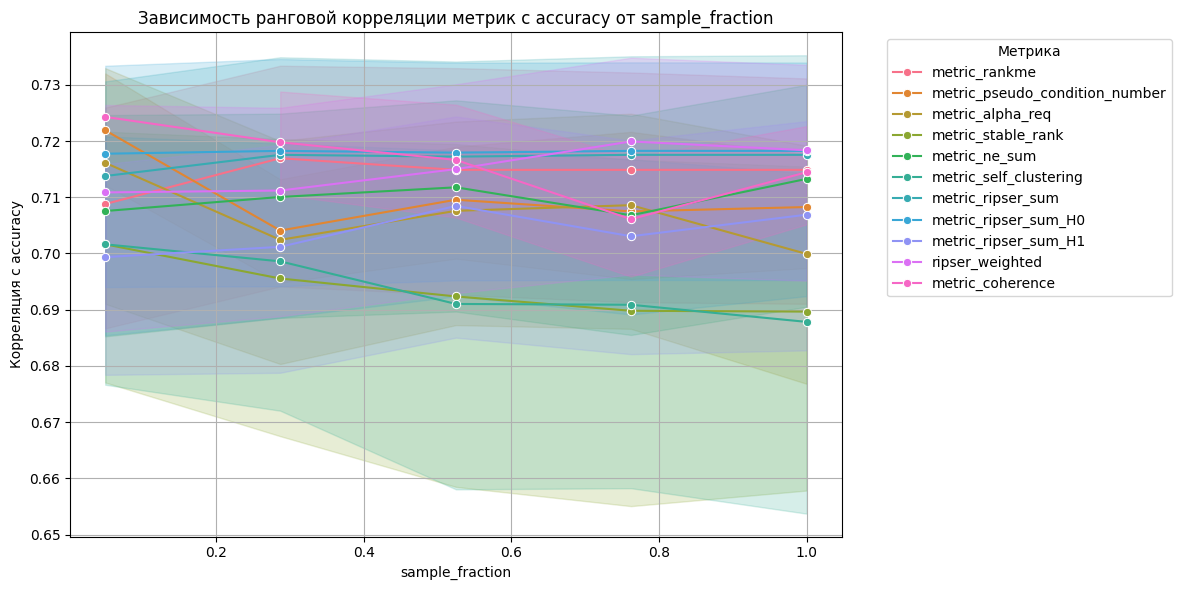

cnt_min


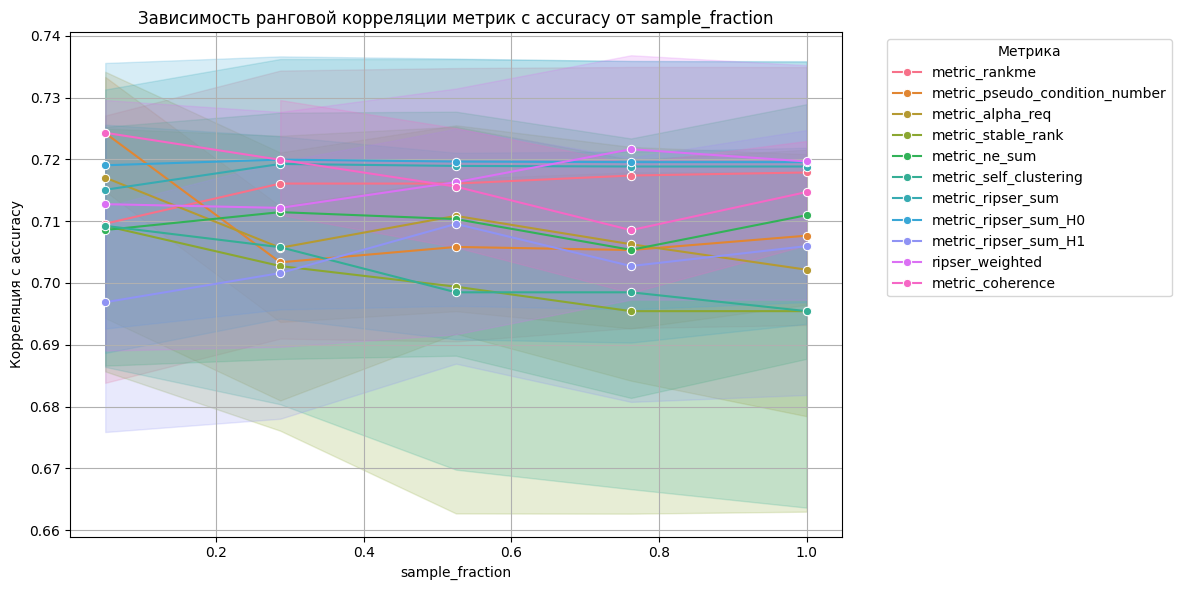

cnt_max


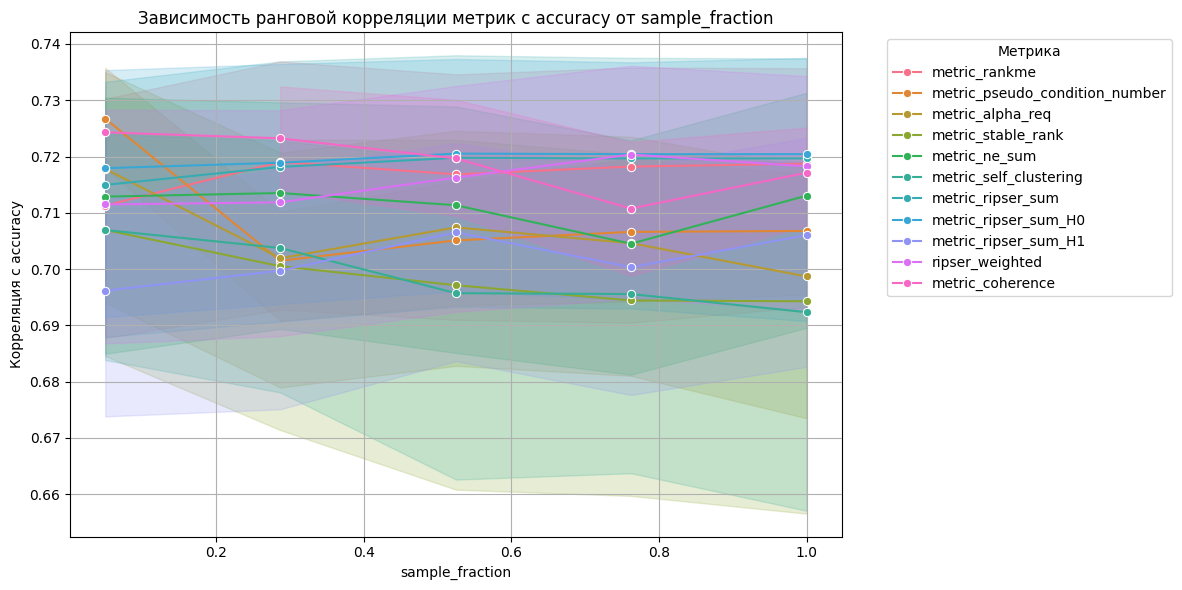

embedding_dim


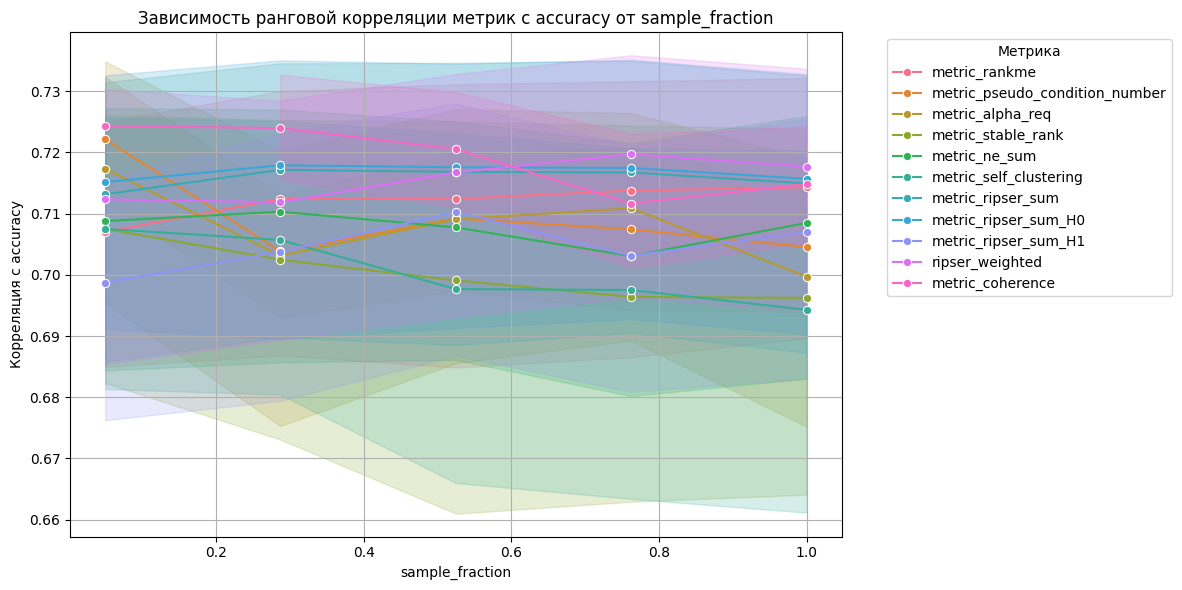

category_embedding_dim


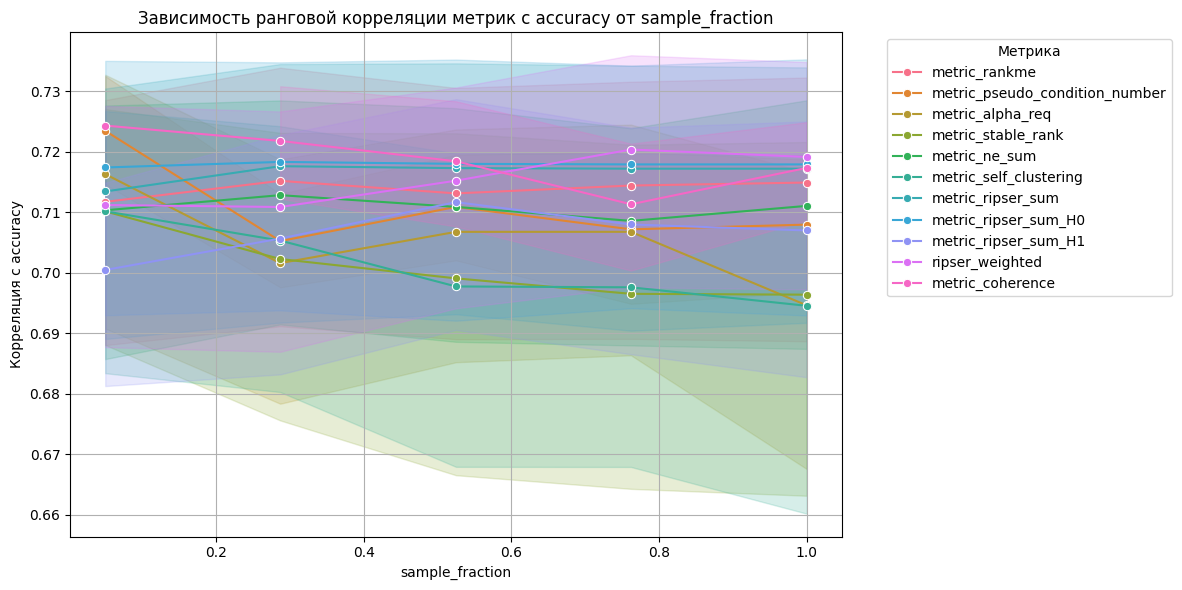

hidden_size


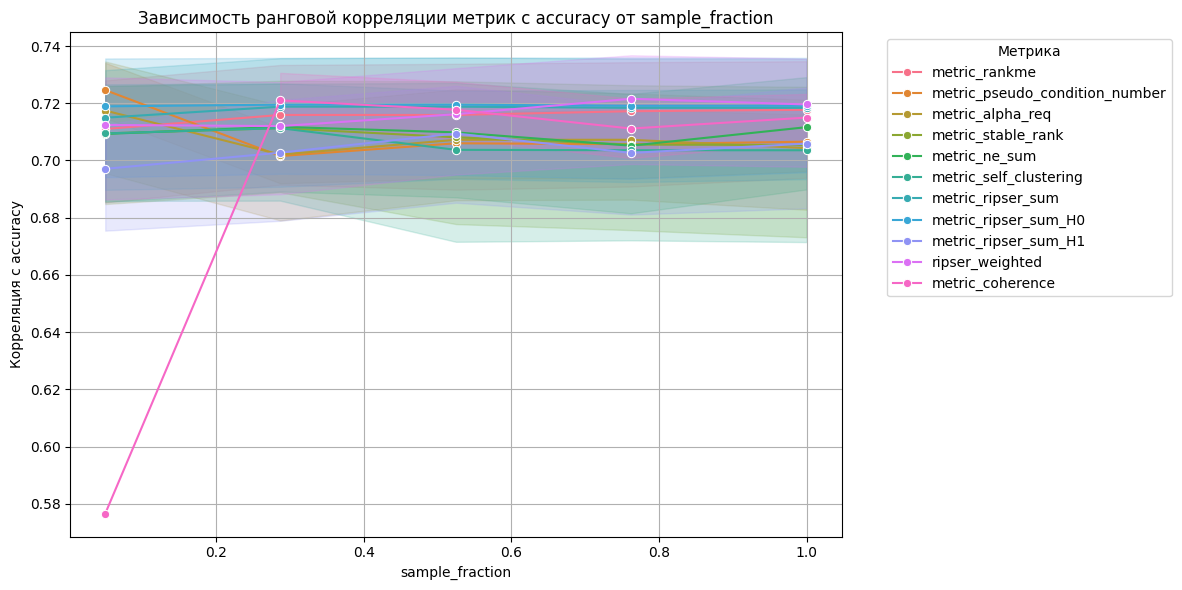

In [128]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()
    

In [129]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ripser_sum_H0              0.718744
metric_ripser_sum                 0.717387
metric_coherence                  0.716468
ripser_weighted                   0.716129
metric_rankme                     0.715176
metric_ne_sum                     0.710956
metric_pseudo_condition_number    0.710185
metric_alpha_req                  0.707456
metric_self_clustering            0.703441
metric_ripser_sum_H1              0.703423
metric_stable_rank                0.703356
Name: auc, dtype: float64
learning_rate
metric
metric_rankme                     0.724682
metric_ripser_sum                 0.719991
metric_ripser_sum_H0              0.719441
ripser_weighted                   0.717824
metric_coherence                  0.717123
metric_ne_sum                     0.715528
metric_alpha_req                  0.715244
metric_self_clustering            0.713888
metric_stable_rank                0.713686
metric_ripser_sum_H1              0.706501
metric_pseudo_condition_number  

/tmp/ipykernel_3643076/655376316.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_corr.values, y=mean_corr.index, palette="viridis")
/tmp/ipykernel_3643076/655376316.py:7: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


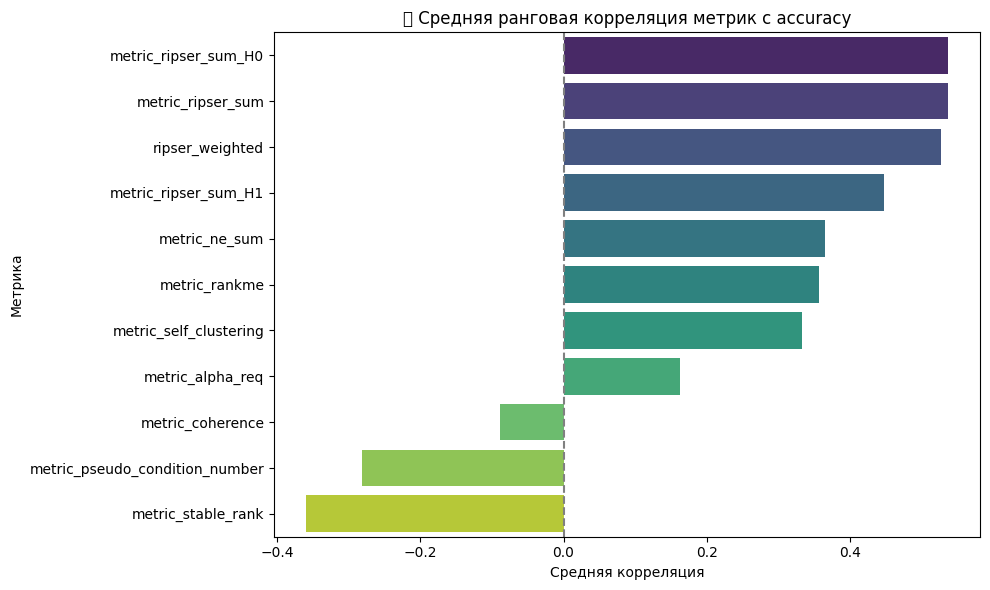

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x=mean_corr.values, y=mean_corr.index, palette="viridis")
plt.title("📊 Средняя ранговая корреляция метрик с accuracy")
plt.xlabel("Средняя корреляция")
plt.ylabel("Метрика")
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

In [15]:
std_corr = spear_corr_df.groupby("metric")["correlation"].std().sort_values()

/tmp/ipykernel_3643076/2625709754.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3643076/2625709754.py:10: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


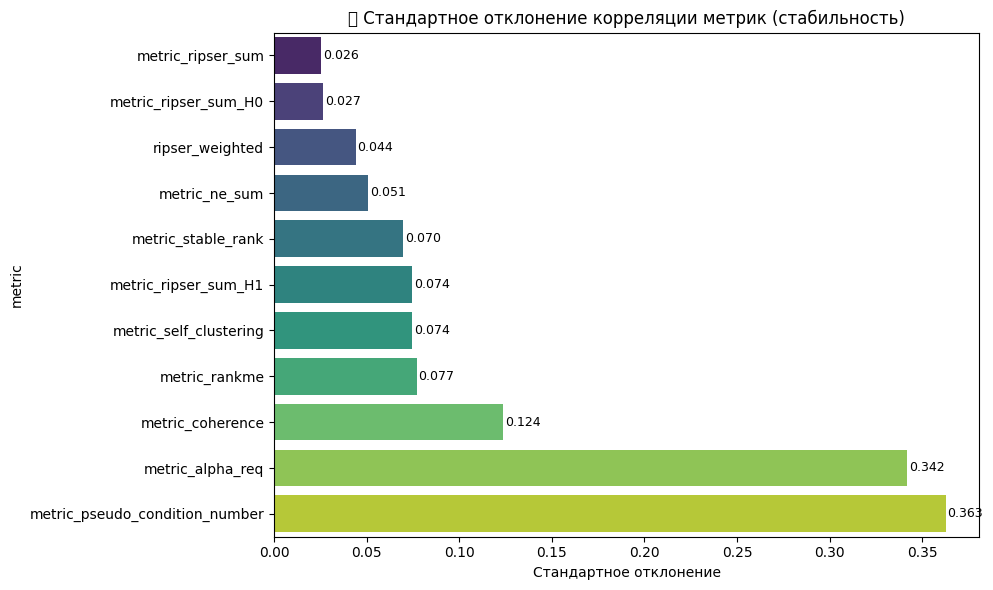

In [24]:
sorted_std = std_corr.sort_values(ascending=True)
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")

for i, v in enumerate(sorted_std.values):
    plt.text(v + 0.001, i, f"{v:.3f}", color='black', ha='left', va='center', fontsize=9)

plt.title("📉 Стандартное отклонение корреляции метрик (стабильность)")
plt.xlabel("Стандартное отклонение")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3255029/3339553728.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: spearmanr(df["sample_fraction"], df["correlation"]).correlation)
/tmp/ipykernel_3255029/3339553728.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trend_corr.values, y=trend_corr.index, palette="magma")
/tmp/ipykernel_3255029/3339553728.py:15: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: Use

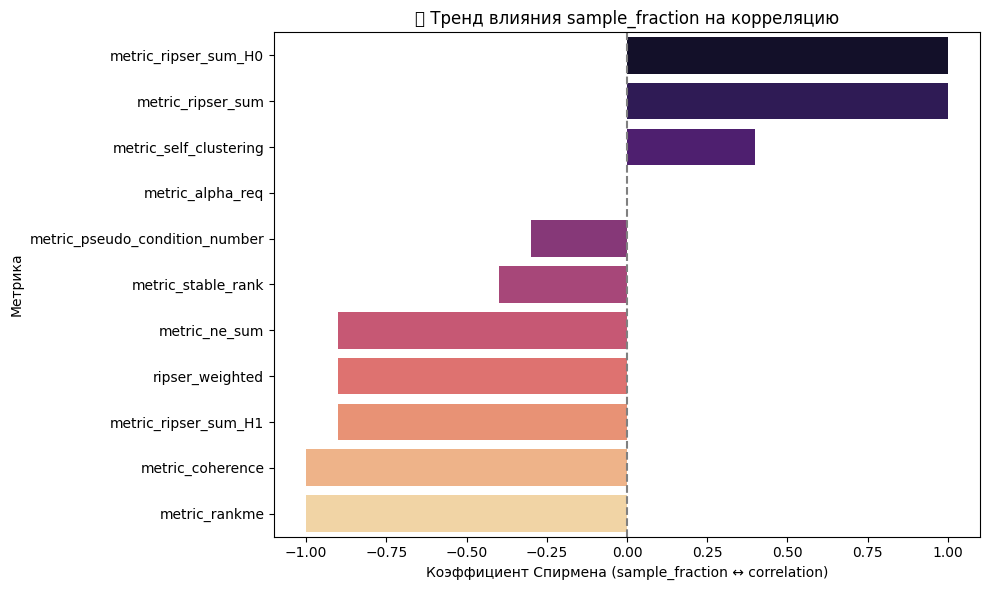

In [10]:
from scipy.stats import spearmanr

trend_corr = (
    corr_df.groupby("metric")
    .apply(lambda df: spearmanr(df["sample_fraction"], df["correlation"]).correlation)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=trend_corr.values, y=trend_corr.index, palette="magma")
plt.title("📈 Тренд влияния sample_fraction на корреляцию")
plt.xlabel("Коэффициент Спирмена (sample_fraction ↔ correlation)")
plt.ylabel("Метрика")
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()


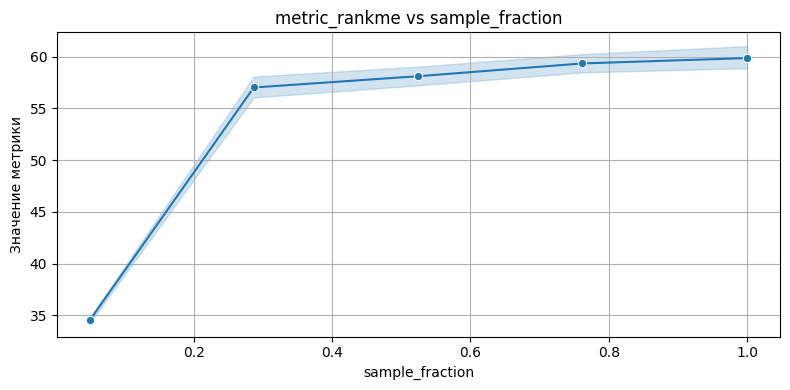

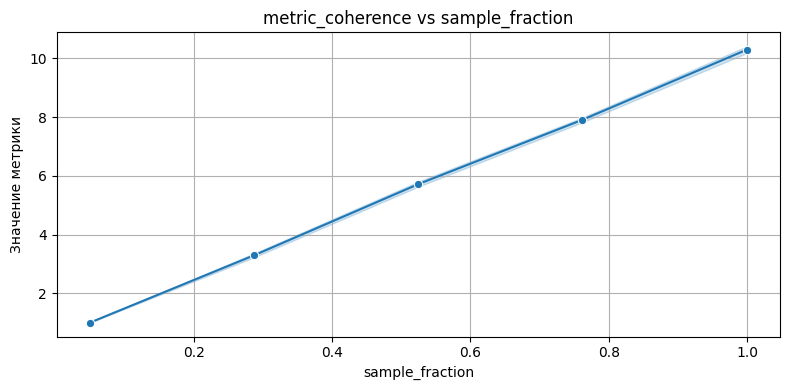

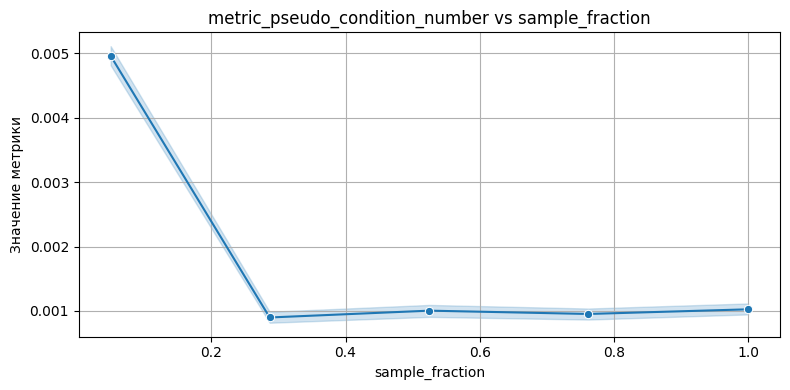

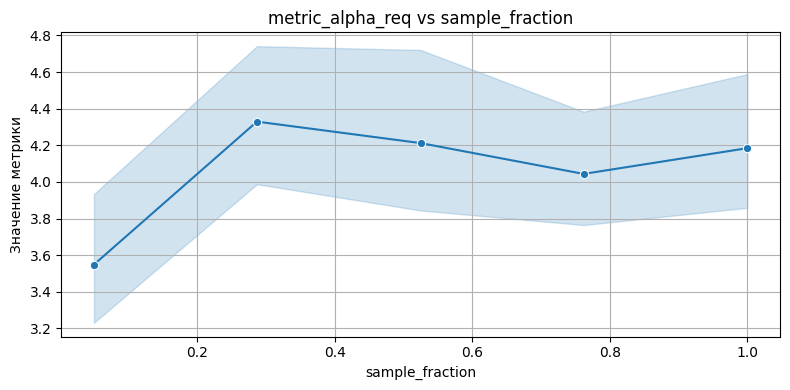

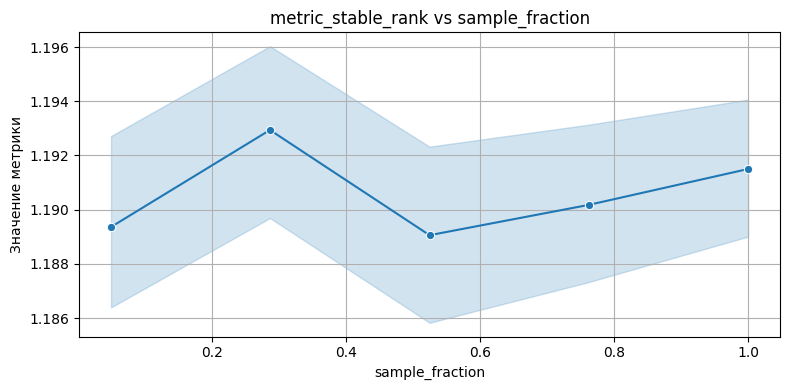

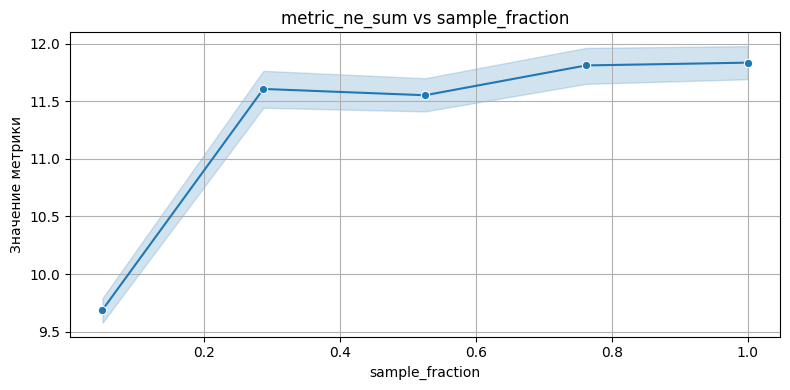

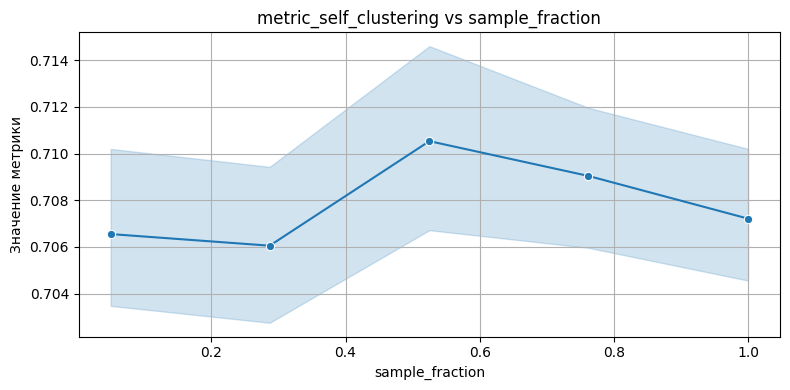

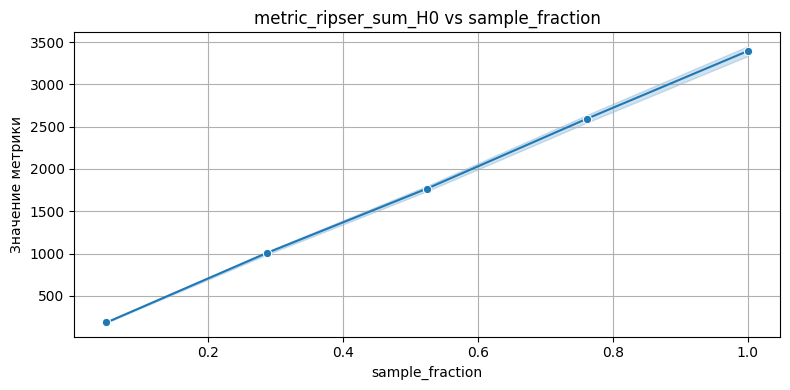

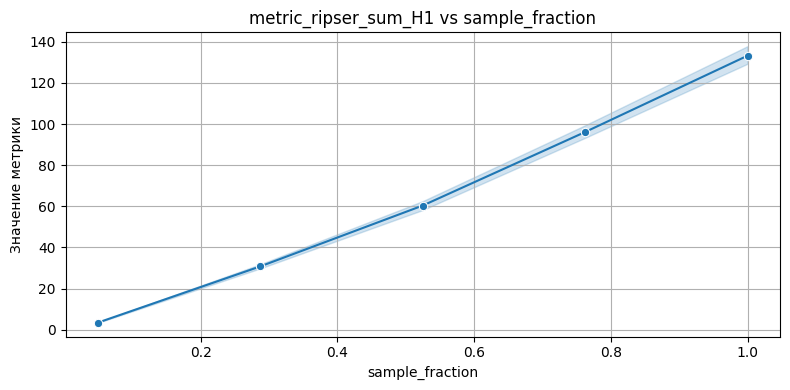

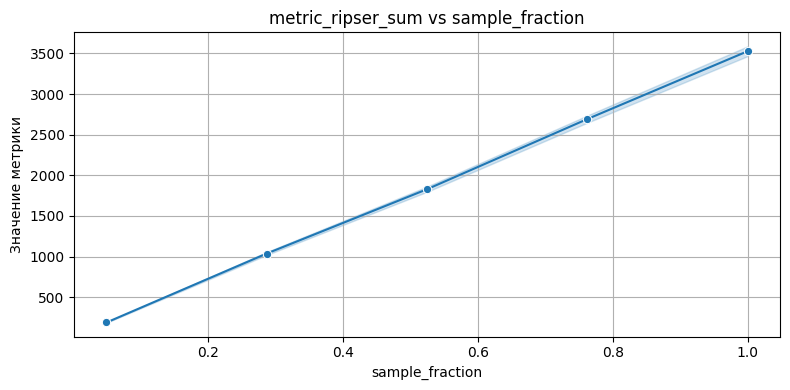

In [ ]:
for metric in metric_columns:
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=df_all, x="sample_fraction", y=metric, marker="o")
    plt.title(f"{metric} vs sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Значение метрики")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [1]:
from collections import defaultdict

def count_paths(start, end, allowed_ops):
    dp = defaultdict(int)
    dp[start] = 1

    for x in range(start, end + 1):
        if 'A' in allowed_ops and x + 3 <= end:
            dp[x + 3] += dp[x]
        if 'B' in allowed_ops and x * 4 <= end:
            dp[x * 4] += dp[x]
        if 'C' in allowed_ops and x * 5 <= end:
            dp[x * 5] += dp[x]
    return dp[end]

# 1 → 362: без B (только A и C)
paths_1_to_362 = count_paths(1, 362, allowed_ops={'A', 'C'})

# 362 → 725: все команды разрешены
paths_362_to_725 = count_paths(362, 725, allowed_ops={'A', 'B', 'C'})

# Общее число программ
total_programs = paths_1_to_362 * paths_362_to_725

print("Ответ:", total_programs)


Ответ: 58
